# HealthConnect Clinic — Week 8
## Data Science Track: Final Model Selection, Documentation & Presentation

**Programme:** AnalystLab Africa Experience Lab

**Project:** HealthConnect Clinic Experience Lab

**Project Title:** Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

**Track:** Data Science

**Week:** 8 — HealthConnect Final Integration, Presentation & Project Showcase

**Version:** 1.0

## Week 8 — Final Integration and Presentation

Week 7 completed the testing and refinement of my Random Forest candidate model: I confirmed it was stable across splits, found and fixed a real overfitting issue, improved its probability calibration, and validated it against Data Analytics' findings. Week 8 moves from a *tested* model to a *final, documented, presentation-ready* modelling outcome — confirming the final candidate, comparing it against the baseline one last time, explaining its business suitability in plain terms, and completing the final HC-POD integration record.

**Highligting to the Week 8 brief:**

| Assignment requirement | Section |
|---|---|
| Week 7 → Week 8 transition | 1 |
| Part 1 — Final integration readiness | 2 |
| Regenerating the final model for presentation | 3 |
| Tasks 1–2 — Reviewing Week 7 results, confirming the final candidate | 4 |
| Tasks 3–4 — Final performance vs. baseline, key metrics | 5 |
| Task 5 — Strengths and weaknesses | 6 |
| Task 6 — Modelling decisions | 7 |
| Task 7 — Business suitability | 8 |
| Task 8 — Incorporating Data Analytics findings | 9 |
| Task 9 — Communicating final requirements to ML Engineering | 10 |
| Tasks 10–11 — Limitations, risks, what the model can/cannot do | 11 |
| Mandatory HC-POD final integration | 12 |
| Final integration matrix | 13 |
| Task 13 — Non-technical stakeholder summary | 14 |
| Saving final artefacts | 15 |


## 1. Week 7 → Week 8 Transition

| # | Item | Summary |
|---|---|---|
| 1 | Main Week 7 output | A systematically tested and refined Random Forest candidate model — depth-reduced to fix overfitting, isotonic-calibrated for trustworthy probabilities, and validated across five independent data splits. |
| 2 | Most important testing result | A 95% bootstrap confidence interval for the model's ROC-AUC improvement over the baseline that excludes zero ([0.0036, 0.0295]) — the improvement is statistically confirmed, not just directionally consistent. |
| 3 | Major issue discovered | A real overfitting gap (training ROC-AUC 0.757 vs. test ROC-AUC 0.683). |
| 4 | What was refined or improved | Reduced Random Forest `max_depth` from 8 to 5 (narrowing the overfitting gap to 0.026 while improving test performance), and applied isotonic probability calibration. |
| 5 | Component now considered ready | The refined and calibrated Random Forest pipeline, saved as `healthconnect_random_forest_model_week7_final.joblib`. |
| 6 | What still needs to be integrated | The Machine Learning Engineering pipeline and Project Management's cost/priority data for setting a deployment threshold. |
| 7 | Track(s) involved in final integration | Data Analytics (validated findings received and used), Machine Learning Engineering, and Project Management (no response). |
| 8 | What this presentation demonstrates | How systematic testing turned an initial baseline into a validated, calibrated candidate model, and how Data Analytics findings were used to check and extend that model's feature set. |



## 2. Part 1 — Final Integration Readiness

| Requirement | My Response |
|---|---|
| What is my final component? | A Random Forest no-show prediction model: depth-reduced (`max_depth=5`) and isotonic-calibrated, trained on the refined feature set established across Weeks 5–7. |
| What problem does it address? | Estimating, before an appointment occurs, the probability that it will result in a no-show — supporting a risk-based prioritisation of reminder/outreach effort. |
| What is its current status? | Tested and refined (Week 7). Finalised and documented (Week 8). Not yet integrated into a production pipeline or deployed. |
| What did I improve during Week 7? | Fixed a real overfitting issue (gap reduced from 0.073 to 0.026) and improved probability calibration, both confirmed with before/after retests. |
| Which other track(s) does my work depend on? | Machine Learning Engineering, to turn this model into a running pipeline; Project Management, to supply the cost data needed to set an operating threshold. |
| Which track(s) depend on my output? | Machine Learning Engineering depends on my final model and its interface specification. |
| What output will I provide? | The final serialised model (`healthconnect_random_forest_model_week7_final.joblib`) and a finalised interface specification (section 10, section 15). |
| What output do I need from another track? | Machine Learning Engineering's pipeline input/output schema and technical constraints; Project Management's cost/priority data for the classification threshold. |
| What evidence demonstrates readiness? | The Week 7 testing record (stability across 5 splits, overfitting fix, calibration improvement, statistically confirmed baseline comparison) and the saved model artefact. |
| What limitations remain? | See section 11. |


# 3.0 Regenerating the Final Model for This Presentation

This is a light recreation to produce the final comparison charts for this presentation. Every decision below (missing-value treatment, feature set, refinement, calibration) was made and justified in Weeks 5–7.


## 3.1 Imorting libraries and Dataset Loading

In [15]:
# Importing the libraries needed to regenerate the final model and its presentation charts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df_raw = pd.read_csv("HealthConnect_Appointment_Data.csv")
print(f"Loaded {df_raw.shape[0]} appointment records and {df_raw.shape[1]} columns.")

Loaded 5000 appointment records and 18 columns.


## 3.2 Reconstructing the Modelling Population

In [8]:
# Recreating the Week 5-7 binary modelling population, missing-value treatment, and feature engineering
df_processed = df_raw[df_raw["appointment_outcome"].isin(["Attended", "No-Show"])].copy()
df_processed["no_show"] = (df_processed["appointment_outcome"] == "No-Show").astype(int)
df_processed["reminder_channel"] = df_processed["reminder_channel"].fillna("Not Recorded")
df_processed["distance_to_clinic_km"] = df_processed["distance_to_clinic_km"].fillna(
    df_processed["distance_to_clinic_km"].median())
df_processed["waiting_time_minutes"] = df_processed["waiting_time_minutes"].fillna(
    df_processed["waiting_time_minutes"].median())
df_processed = df_processed.drop_duplicates().copy()

cols_to_drop = ["appointment_id", "age_group", "booking_date", "appointment_date",
                "appointment_outcome", "waiting_time_minutes"]
df_cleaned = df_processed.drop(columns=cols_to_drop, errors="ignore")

df_feature = df_cleaned.copy()
df_feature["prev_no_show_rate"] = (
    df_feature["previous_no_shows"] / df_feature["previous_appointments"].replace(0, np.nan)).fillna(0)
df_feature["lead_time_band"] = pd.cut(
    df_feature["booking_lead_days"], bins=[-0.1, 7, 21, 40, 60],
    labels=["0-7 days", "8-21 days", "22-40 days", "41-60 days"])
df_feature["high_prev_no_show"] = (df_feature["previous_no_shows"] >= 2).astype(int)
df_feature["long_distance"] = (
    df_feature["distance_to_clinic_km"] > df_feature["distance_to_clinic_km"].median()).astype(int)
df_feature["no_reminder"] = (df_feature["reminder_sent"] == "No").astype(int)

NUMERIC_FEATURES = ["age", "previous_appointments", "prev_no_show_rate"]
CATEGORICAL_FEATURES = ["gender", "appointment_type", "appointment_day", "appointment_time",
                         "reminder_sent", "reminder_channel", "lead_time_band"]
BINARY_FEATURES = ["high_prev_no_show", "long_distance", "no_reminder"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + BINARY_FEATURES
REFINED_NUMERIC = NUMERIC_FEATURES + ["booking_lead_days", "distance_to_clinic_km", "previous_no_shows"]
REFINED_FEATURES = REFINED_NUMERIC + CATEGORICAL_FEATURES + BINARY_FEATURES
TARGET = "no_show"

df_model = df_feature[ALL_FEATURES + [TARGET] + ["patient_id"]].copy()
df_refined_model = df_feature[REFINED_FEATURES + [TARGET] + ["patient_id"]].copy()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(df_model[ALL_FEATURES], df_model[TARGET], groups=df_model["patient_id"]))

X_train = df_model[ALL_FEATURES].iloc[train_idx].copy()
X_test = df_model[ALL_FEATURES].iloc[test_idx].copy()
Xr_train = df_refined_model[REFINED_FEATURES].iloc[train_idx].copy()
Xr_test = df_refined_model[REFINED_FEATURES].iloc[test_idx].copy()
y_train = df_model[TARGET].iloc[train_idx].copy()
y_test = df_model[TARGET].iloc[test_idx].copy()
groups_train = df_model["patient_id"].iloc[train_idx]

def build_pipeline(numeric_feats, categorical_feats, binary_feats, model):
    """Assembling a preprocessing-plus-model pipeline for a given feature set and estimator."""
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_feats),
        ("bin", "passthrough", binary_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_feats),
    ])
    return Pipeline([("preprocess", pre), ("model", model)])

print(f"Training set: {len(X_train):,} appointments | Test set: {len(X_test):,} appointments")

Training set: 3,771 appointments | Test set: 966 appointments


## 3.3 Refitting the Baseline and Final Random Forest Models

In [17]:
# Refitting the baseline and the final (depth-refined, calibrated) Random Forest
baseline_pipeline = build_pipeline(
    NUMERIC_FEATURES, CATEGORICAL_FEATURES, BINARY_FEATURES,
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
)
baseline_pipeline.fit(X_train, y_train)
y_pred_base = baseline_pipeline.predict(X_test)
y_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]

refined_rf_pipeline = build_pipeline(
    REFINED_NUMERIC, CATEGORICAL_FEATURES, BINARY_FEATURES,
    RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=15, random_state=42, class_weight="balanced")
)
refined_rf_pipeline.fit(Xr_train, y_train)

final_pipeline = CalibratedClassifierCV(refined_rf_pipeline, method="isotonic", cv=5)
final_pipeline.fit(Xr_train, y_train)
y_pred_final = final_pipeline.predict(Xr_test)
y_proba_final = final_pipeline.predict_proba(Xr_test)[:, 1]

print(f"Baseline — Test Accuracy: {accuracy_score(y_test, y_pred_base):.3f} | "
      f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Final model — Test Accuracy: {accuracy_score(y_test, y_pred_final):.3f} | "
      f"Test ROC-AUC: {roc_auc_score(y_test, y_proba_final):.3f}")

Baseline — Test Accuracy: 0.616 | Test ROC-AUC: 0.671
Final model — Test Accuracy: 0.643 | Test ROC-AUC: 0.689


# 4. Reviewing Week 7 Results and Confirming the Final Candidate Model

**Week 7 testing results, reviewed:**

| Test | Result |
|---|---|
| Stability across 5 independent splits | Random Forest outperformed the baseline on 5 of 5 splits (mean ROC-AUC 0.6856 vs. 0.6763) |
| Segment-level validation | Broadly consistent; Specialist Consultation (AUC 0.607) and patients 65+ (AUC 0.665) were the weakest segments |
| Overfitting check | A real gap found (train ROC-AUC 0.757 vs. test 0.683) |
| Complexity refinement | `max_depth` reduced from 8 to 5; gap narrowed to 0.026; test ROC-AUC improved to 0.688 |
| Probability calibration | Isotonic calibration adopted; Brier score improved from 0.224867 to 0.223458 |
| Cost-sensitive threshold | Highly sensitive to an assumption Project Management has not supplied (0.25 to 0.50 depending on the cost ratio tested) |
| Statistical significance | 95% bootstrap CI for the ROC-AUC improvement: [0.0036, 0.0295] — entirely positive |

**Final candidate model, confirmed:** Random Forest, `max_depth=5`, `min_samples_leaf=15`, trained on the refined feature set (14 features spanning demographic, booking, and history variables), with isotonic probability calibration applied. This is the same model saved at the end of Week 7.


# 5.0 Final Performance Comparison Against the Baseline


In [10]:
# Building the final comparison table between the baseline and the final model
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression (Baseline)", "Random Forest (Final, Refined & Calibrated)"],
    "Accuracy": [accuracy_score(y_test, y_pred_base), accuracy_score(y_test, y_pred_final)],
    "Precision": [precision_score(y_test, y_pred_base), precision_score(y_test, y_pred_final)],
    "Recall": [recall_score(y_test, y_pred_base), recall_score(y_test, y_pred_final)],
    "F1": [f1_score(y_test, y_pred_base), f1_score(y_test, y_pred_final)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_base), roc_auc_score(y_test, y_proba_final)],
}).set_index("Model").round(3)
comparison_table

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression (Baseline),0.616,0.615,0.619,0.617,0.671
"Random Forest (Final, Refined & Calibrated)",0.643,0.640,0.652,0.646,0.689


## Interpretation

### Visualization
The table compares the baseline Logistic Regression with the final Random Forest across Accuracy, Precision, Recall, F1, and ROC-AUC.

### Observation
The final Random Forest performs higher on all five metrics, including ROC-AUC (**0.689 vs. 0.671**) and Recall (**0.652 vs. 0.619**).

### Decision
The final Random Forest is retained as the final model because it shows improved performance across all reported evaluation metrics compared with the baseline.

## 5.1 Plotting the Final ROC Curve Comparison

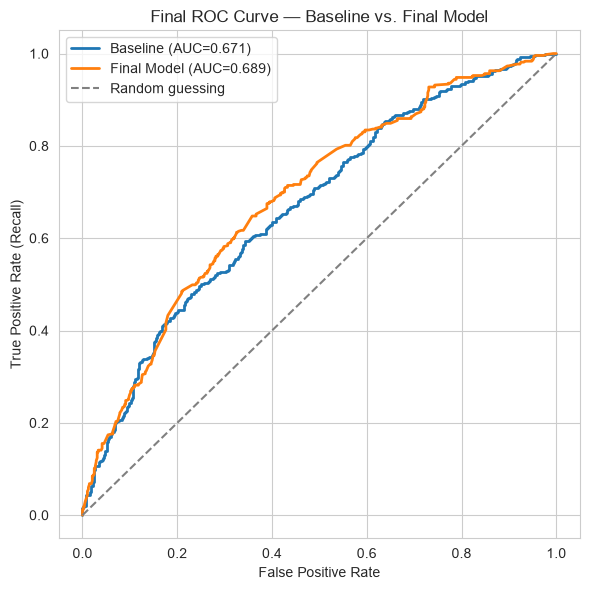

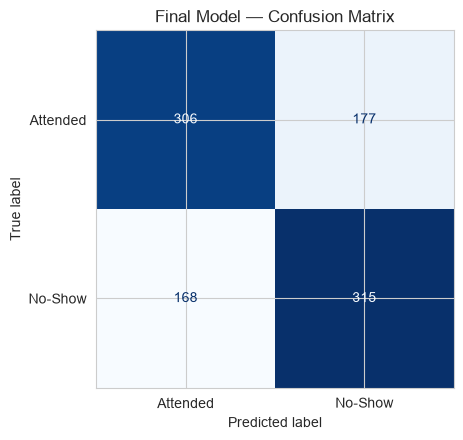

In [18]:
# Plotting the final ROC curve comparison for the presentation
fig, ax = plt.subplots(figsize=(6, 6))
fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
fpr_f, tpr_f, _ = roc_curve(y_test, y_proba_final)
ax.plot(fpr_b, tpr_b, label=f"Baseline (AUC={roc_auc_score(y_test, y_proba_base):.3f})", linewidth=2)
ax.plot(fpr_f, tpr_f, label=f"Final Model (AUC={roc_auc_score(y_test, y_proba_final):.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guessing")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("Final ROC Curve — Baseline vs. Final Model")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final), display_labels=["Attended", "No-Show"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Final Model — Confusion Matrix")
plt.tight_layout()
plt.show()

## Interpretation — Final Model Confusion Matrix

**Visualization:** 2×2 grid showing TN=306, FP=177, FN=168, TP=315 on the test set. The two diagonal cells (correct predictions) are the darkest; off-diagonal cells (errors) are lighter and roughly balanced.

**Observation:** correct predictions (306+315=621) vs errors (177+168=345) → accuracy ≈ 64%. Errors are near-symmetric: FP (177) slightly higher than FN (168). The model is slightly biased toward predicting "No-Show" but not strongly. Recall on No-Show = 315/(315+168) ≈ 65%; recall on Attended = 306/(306+177) ≈ 63%. No severe class imbalance problem.

**Decision:** the model performs reasonably and evenly across both classes, with no strong directional bias — suitable for **risk-ranking / prioritisation** (flagging higher-risk appointments for outreach), not for automated decisions. The near-equal FP/FN split means threshold tuning can shift the balance depending on real cost data. The weak segments identified in Specialist Consultation, 65+ remain the main limitation.

**Most relevant evaluation metrics for this presentation:** ROC-AUC (overall discrimination), recall (the share of true no-shows actually caught), and the confusion matrix (the concrete trade-off in whole appointments). The final model improves ROC-AUC over the baseline, and that improvement is statistically confirmed, not attributable to chance.


## 6. Model Strengths and Weaknesses

**Strengths:**
- Statistically confirmed improvement over the baseline (bootstrap CI excludes zero), not just a single-split coincidence.
- Consistent performance advantage across 5 independently drawn splits (5 of 5 wins).
- Well-calibrated probabilities, particularly in the highest-risk decile — the part of the output a prioritisation use case relies on most.
- Overfitting was identified and fixed with no performance trade-off.

**Weaknesses:**
- Two segments — Specialist Consultation appointments and patients aged 65+ — are measurably harder for the model to predict than the rest of the population.
- Absolute performance is moderate (ROC-AUC around 0.68–0.69): useful for ranking risk, not for confident individual-level prediction.
- The correct classification threshold for real use depends on cost data not currently available.

**Additional context on the 65+ weakness, from Data Analytics:** a deeper analysis of the 65+ segment (n=1,241; overall no-show rate 45.12%) shows that the same risk factors driving the overall model — booking lead time and previous no-show history — vary just as strongly *within* this segment as they do across the whole population. No-show rates within the 65+ group rise from 29.12% (0–7 day lead time) to 62.09% (46–60 days), and from 37.72% (no previous no-shows) to 61.09% (2+ previous no-shows). Reminder status makes almost no difference within this segment (46.04% vs. 44.78%, a 1.26-point gap). Recomputing these same breakdowns independently produces the same pattern (29.12%→31.18–66.93% across lead time, similar rise across previous no-show history), confirming real, usable signal exists within this segment — the model's weaker performance here is therefore not a data problem, but a sign that the model is not fully exploiting signal it already has access to for this specific age group.


## 7. Documenting Important Modelling Decisions

| Week | Decision | Why |
|---|---|---|
| 5 | Chose Logistic Regression as an interpretable baseline | Establishes a simple, explainable reference point before trying anything more complex |
| 5 | Dropped `booking_lead_days`, `distance_to_clinic_km`, `previous_no_shows` in favour of engineered versions | Reduced correlation for the linear model's coefficient stability |
| 6 | Reinstated those three variables for tree-based models only | Cross-validation showed tree models lose real predictive information without them |
| 6 | Selected Random Forest as the primary candidate | Highest cross-validated ROC-AUC among Decision Tree, Random Forest, and Gradient Boosting |
| 7 | Reduced Random Forest `max_depth` from 8 to 5 | Fixed a real, measured overfitting gap with no loss in test performance |
| 7 | Adopted isotonic probability calibration | Measurably improved probability trustworthiness at the high-risk end |
| 7 | Declined to adopt a discrete "high-risk combination" flag suggested by a Data Analytics finding | Tested with cross-validation; produced no improvement, since the model already captures the pattern through its own feature splits |
| 8 | Declined to adopt a senior/long-lead-time interaction flag suggested by Data Analytics' 65+ deep dive | Tested with cross-validation; overall CV ROC-AUC and the 65+ segment's own AUC both moved slightly in the wrong direction (0.6762 to 0.6755 overall; 0.6804 to 0.6781 within the 65+ segment) |
| 7 | Declined to set a single classification threshold | The correct threshold depends on real cost data not currently available |


## 8. Business Suitability of the Model

The final model is suitable for **risk-ranking and prioritisation** — helping HealthConnect direct limited reminder or outreach capacity toward the appointments most likely to be missed, rather than treating every booking the same way. It is **not** suitable for fully automated scheduling decisions: its absolute performance is moderate, two patient/appointment segments remain harder to predict, and no cost data yet exists to set the threshold at which a "high risk" label should trigger an action.

**A concrete, realistic use case:** ranking tomorrow's appointments by predicted no-show probability and directing extra reminder calls toward the top of that list, rather than calling every patient or none at all.


## 9. Incorporating Validated Findings from Data Analytics

Six validated Data Analytics findings on booking lead time, reminder status, previous no-show history, waiting time, distance, and age were received and independently recomputed against my own data — one matched exactly (waiting time: 24.29 vs. 24.20 minutes), and the other five matched in direction and magnitude with small, explainable gaps. Their sharpest finding (an 82–84% no-show rate for a specific high-risk combination) was tested as an actual model feature; it did not improve the model.

Data Analytics also produced a deeper, descriptive analysis specifically of the 65+ segment, given its identification as a weak segment in Week 7 testing (section 6). That analysis shows real, substantial variation in no-show behaviour within the 65+ group across booking lead time (29.12% to 62.09%) and previous no-show history (37.72% to 61.09%), with reminder status making little difference (a 1.26-point gap). I independently recomputed all three breakdowns and found the same pattern. I then tested whether an explicit senior/long-lead-time flag, built directly from this finding, would improve the model — it did not (section 7), which indicates the Random Forest already captures this interaction through its own splits on age and lead time individually, rather than needing it engineered as a separate feature.


## 10. Communicating Final Model Requirements to Machine Learning Engineering

The model requirements for Machine Learning Engineering are finalised below as a concrete specification, ready for that track to build against.


In [12]:
# Finalising the model interface specification for Machine Learning Engineering
model_interface_spec = pd.DataFrame({
    "field": ["numeric_features", "binary_features", "categorical_features",
              "target_variable", "output_format", "model_file"],
    "value": [
        ", ".join(REFINED_NUMERIC),
        ", ".join(BINARY_FEATURES),
        ", ".join(CATEGORICAL_FEATURES),
        "no_show (1 = No-Show, 0 = Attended)",
        "predict_proba()[:, 1] for a calibrated no-show probability; predict() for a 0/1 label at a chosen threshold",
        "healthconnect_random_forest_model_week7_final.joblib",
    ]
})
model_interface_spec.to_csv("healthconnect_model_interface_spec_week8_final.csv", index=False)
print("Final interface specification saved: healthconnect_model_interface_spec_week8_final.csv")

Final interface specification saved: healthconnect_model_interface_spec_week8_final.csv


## 11. Model Limitations, Risks, and What It Can and Cannot Be Used For

**What this model CAN be used for:**
- Ranking appointments by relative no-show risk, to prioritise a limited amount of outreach effort.
- Flagging the general behavioural and booking patterns most associated with no-shows (long lead time, prior no-show history) for HealthConnect's own understanding.

**What this model CANNOT be used for:**
- Making automated, individual scheduling or booking decisions (e.g. auto-cancelling or auto-double-booking a slot).
- Reliable prediction for Specialist Consultation appointments or patients aged 65+, where its performance is measurably weaker even after testing a feature built specifically to address the 65+ gap.
- Any use requiring a precise classification threshold, since the correct threshold depends on cost data not currently available.

**Limitations and risks:**
- Moderate absolute performance (ROC-AUC ~0.68–0.69) — useful for ranking, not high-confidence individual prediction.
- Two persistently weak segments; for the 65+ segment specifically, real usable signal exists (confirmed independently against Data Analytics' deeper analysis) but the model is not yet capturing it as well as it captures the same signal elsewhere in the population.
- **Machine Learning Engineering:** contacted regarding pipeline integration; no response received. Their pipeline input/output schema and technical constraints remain unavailable, so compatibility between this model and any ML Engineering pipeline has not been confirmed.
- **Project Management:** the cost/priority data needed to set a real classification threshold has not been supplied. The threshold analysis in Week 7 remains illustrative rather than final.
- No integration testing has occurred with a real ML pipeline, and no production deployment threshold exists.
- Trained on a fictional, synthetic dataset — every finding describes this dataset only.


## 12. Mandatory HC-POD Final Integration

| # | Item | My Response |
|---|---|---|
| 1 | Track collaborated with | Data Analytics |
| 2 | Dependency | My model's feature choices and segment-weakness findings needed checking against independently produced behavioural findings |
| 3 | Output received | Six validated Week 7 findings, plus a deeper descriptive analysis of the 65+ segment produced specifically in response to my Week 7 finding that this segment was a model weak spot |
| 4 | Output provided | An independent recomputation confirming all findings, plus the results of testing two features built directly from Data Analytics findings (a high-risk combination flag, and a senior/long-lead-time flag) — neither improved the model, and both results were documented with evidence |
| 5 | Final integration activity | Cross-validating features built directly from Data Analytics findings, using the same evaluation protocol as every other model decision in this project |
| 6 | What changed | Confidence in the final feature set was strengthened with independent, cross-track evidence from two rounds of testing rather than resting on Data Science's analysis alone |
| 7 | How the change improved the solution | The final model's feature set and its known weak segment (65+) are now both validated from two independent analytical angles — a stronger, better-documented basis for the business recommendation in section 8 |
| 8 | Evidence | The recomputation and cross-validation results in section 9 and section 7 |
| 9 | Contribution to the final presentation | Demonstrates genuine cross-track collaboration with a real, evidenced outcome across two separate rounds, not just a description of intent to collaborate |

No equivalent final integration activity occurred with Machine Learning Engineering or Project Management (section 11).


## 13. HealthConnect Final Integration Matrix — My Actual Relationships

| Relationship | Status |
|---|---|
| Data Analytics → Data Science | Validated findings received, independently checked, two tested as features (section 9, section 12) |
| Data Science → Machine Learning Engineering | Final model and interface specification prepared (section 10, section 15); not yet exchanged |
| Machine Learning Engineering → Data Science | No pipeline requirements or constraints received (section 11) |
| Data Science → Project Management | Cost/priority data requirement documented; requested but no response |
| Project Management → Data Science | No cost/priority data or coordination response received (section 11) |


## 14. Model Summary for Non-Technical Stakeholders

**What was built:** a tool that looks at a booked appointment and estimates how likely it is to be missed, using information already collected at booking time (how far ahead it was booked, the patient's past attendance, distance to the clinic, and similar factors).

**How well it works:** better than guessing, and confirmed through repeated testing to be a genuine improvement over a simpler first version — not just a lucky result on one test.

**How it could help HealthConnect:** by ranking upcoming appointments from highest to lowest risk, staff could focus limited reminder-call time on the appointments most likely to be missed, instead of treating every booking the same way.

**What it cannot do yet:** make automatic scheduling decisions on its own, reliably judge two specific groups of patients (those seeing a specialist, and patients over 65 — even after testing an extra feature aimed specifically at the second group), or tell staff exactly which risk score should trigger a reminder call, since that depends on cost information the clinic has not yet provided.


## 15. Saving Final Artefacts


In [19]:
# Saving the final model regenerated in this notebook as the Week 8 final artefact
joblib.dump(final_pipeline, "healthconnect_random_forest_model_week8_final.joblib")
print("Final model saved: healthconnect_random_forest_model_week8_final.joblib")
print("Final interface specification: healthconnect_model_interface_spec_week8_final.csv")

Final model saved: healthconnect_random_forest_model_week8_final.joblib
Final interface specification: healthconnect_model_interface_spec_week8_final.csv
